# 09. SHAP-анализ лучшей модели (XGBoost)

В этом ноутбуке:
- загрузка валидационных данных и обученной модели XGBoost
- расчёт SHAP-значений на подвыборке (1000 записей)
- построение глобальных графиков важности признаков (summary plot)
- построение dependence plots для двух наиболее важных признаков
- локальное объяснение предсказаний (waterfall plots) для двух заёмщиков (дефолт и не дефолт)
- сохранение графиков в папку отчёта

### 1. Импорт библиотек и настройка путей

In [3]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import shap
import os

# Создаём папку для графиков SHAP
SHAP_DIR = '../reports/figures/09_shap_analysis'
os.makedirs(SHAP_DIR, exist_ok=True)

# Настройки визуализации (чтобы графики не перегружали память)
plt.rcParams['figure.dpi'] = 100

### 2. Загрузка данных и модели

In [4]:
# Загрузка валидационных данных (масштабированные)
X_val = np.load('../data/processed/X_val_scaled.npy')
y_val = np.load('../data/processed/y_val.npy')

# Загрузка лучшей модели (XGBoost)
with open('../models/xgboost.pkl', 'rb') as f:
    best_model = pickle.load(f)

print(f"Размер валидационной выборки: {X_val.shape}")
print(f"Модель: XGBoost")

# Имена признаков (должны соответствовать порядку при обучении)
feature_names = ['RevolvingUtilizationOfUnsecuredLines', 'age', 
                 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 
                 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
                 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
                 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

Размер валидационной выборки: (29944, 10)
Модель: XGBoost


### 3. Выбор подвыборки для SHAP (для ускорения)

In [5]:
# Для SHAP-анализа используем случайную подвыборку из 1000 записей
np.random.seed(42)
sample_indices = np.random.choice(X_val.shape[0], 1000, replace=False)
X_sample = X_val[sample_indices]
y_sample = y_val[sample_indices]

print(f"Подвыборка для SHAP: {X_sample.shape[0]} записей")

Подвыборка для SHAP: 1000 записей


### 4. Расчёт SHAP-значений (TreeExplainer)

In [6]:
# Создаём объяснитель для дерева (XGBoost)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

print("SHAP-значения рассчитаны.")

SHAP-значения рассчитаны.


### 5. Глобальная важность признаков (Summary Plot)

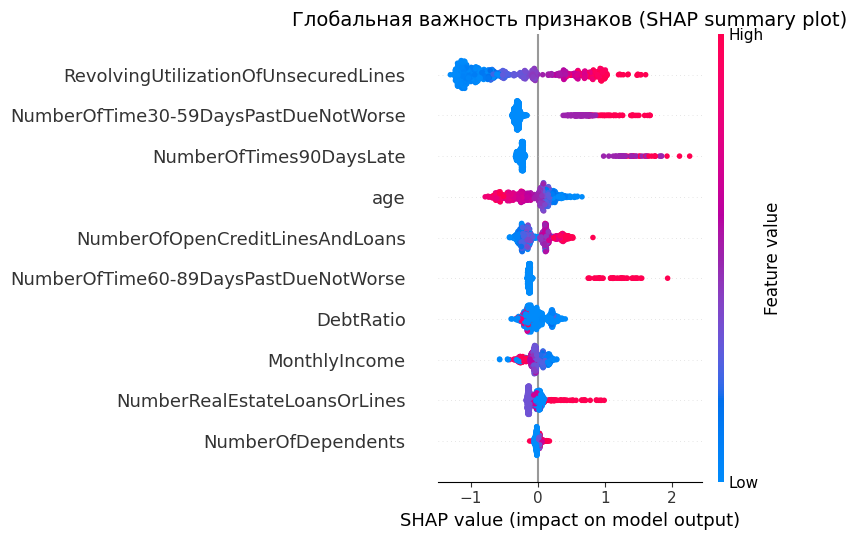

In [13]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
plt.title('Глобальная важность признаков (SHAP summary plot)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SHAP_DIR, 'shap_summary_plot.png'), bbox_inches='tight')
plt.show()

### 6. Dependence plots для двух самых важных признаков

<Figure size 800x600 with 0 Axes>

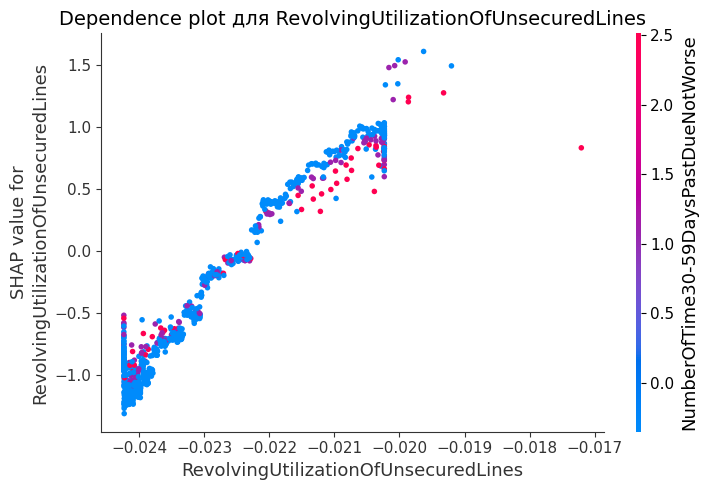

<Figure size 800x600 with 0 Axes>

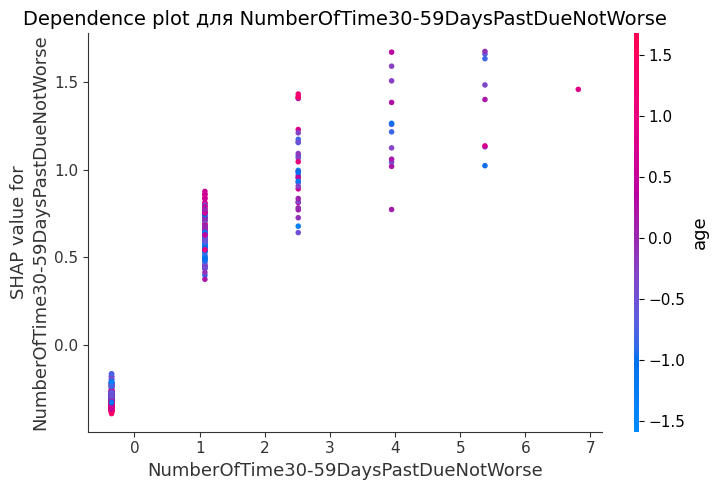

In [ ]:
# Определим два самых важных признака по SHAP
top_features = ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTime30-59DaysPastDueNotWorse']

for feature in top_features:
    idx = feature_names.index(feature)
    plt.figure(figsize=(8, 6))
    shap.dependence_plot(idx, shap_values, X_sample, feature_names=feature_names, show=False)
    plt.title(f'Dependence plot для {feature}', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(SHAP_DIR, f'shap_dependence_{feature}.png'), bbox_inches='tight')
    plt.show()

### 7. Выбор двух заёмщиков для локального объяснения

In [9]:
# Выбираем одного заёмщика с дефолтом (y=1) и одного без дефолта (y=0)
indices_default = np.where(y_sample == 1)[0]
indices_nondefault = np.where(y_sample == 0)[0]

if len(indices_default) > 0 and len(indices_nondefault) > 0:
    idx_default = indices_default[0]
    idx_nondefault = indices_nondefault[0]
else:
    # если в подвыборке нет дефолтов, берём любые
    idx_default = 0
    idx_nondefault = 1

print(f"Индекс заёмщика с дефолтом: {idx_default}")
print(f"Индекс заёмщика без дефолта: {idx_nondefault}")

Индекс заёмщика с дефолтом: 3
Индекс заёмщика без дефолта: 0


### 8. Локальное объяснение (Waterfall plot) для двух заёмщиков

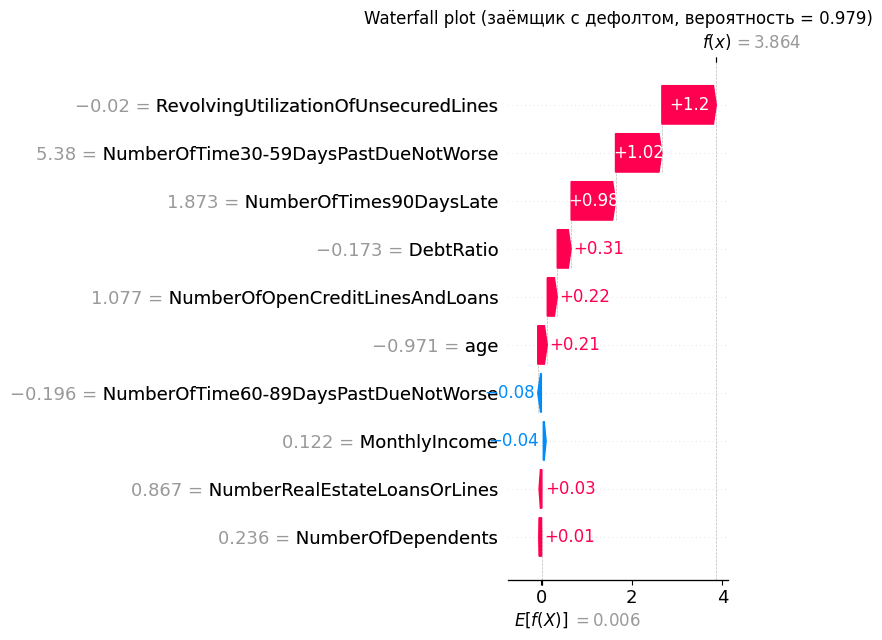

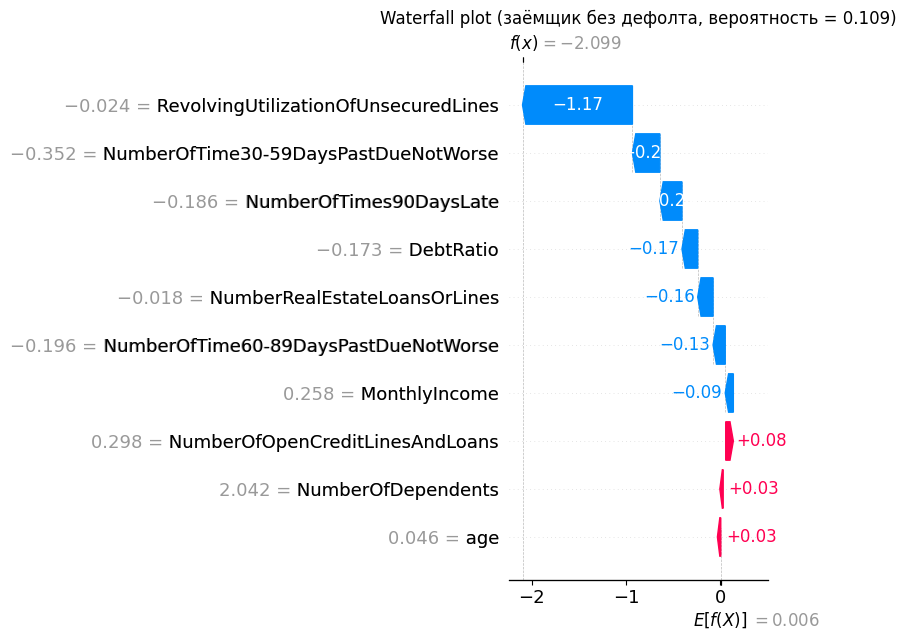

In [10]:
# Для заёмщика с дефолтом
plt.figure(figsize=(12, 6))
shap.waterfall_plot(shap.Explanation(values=shap_values[idx_default],
                                      base_values=explainer.expected_value,
                                      data=X_sample[idx_default],
                                      feature_names=feature_names),
                    show=False)
plt.title(f'Waterfall plot (заёмщик с дефолтом, вероятность = {best_model.predict_proba(X_sample[idx_default:idx_default+1])[0,1]:.3f})', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(SHAP_DIR, 'shap_waterfall_default.png'), bbox_inches='tight')
plt.show()

# Для заёмщика без дефолта
plt.figure(figsize=(12, 6))
shap.waterfall_plot(shap.Explanation(values=shap_values[idx_nondefault],
                                      base_values=explainer.expected_value,
                                      data=X_sample[idx_nondefault],
                                      feature_names=feature_names),
                    show=False)
plt.title(f'Waterfall plot (заёмщик без дефолта, вероятность = {best_model.predict_proba(X_sample[idx_nondefault:idx_nondefault+1])[0,1]:.3f})', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(SHAP_DIR, 'shap_waterfall_nondefault.png'), bbox_inches='tight')
plt.show()

### 9. Выводы (для информации)

In [11]:
print("SHAP-анализ завершён. Все графики сохранены в папку reports/figures/09_shap_analysis/")
print("На основе summary plot можно сделать вывод о ключевых факторах дефолта.")
print("Waterfall plots демонстрируют, какие признаки повлияли на решения для конкретных заёмщиков.")

SHAP-анализ завершён. Все графики сохранены в папку reports/figures/09_shap_analysis/
На основе summary plot можно сделать вывод о ключевых факторах дефолта.
Waterfall plots демонстрируют, какие признаки повлияли на решения для конкретных заёмщиков.
